# Section 3: Build, Train or Estimate the ML Model --> Chapter 15. Anomaly Detection

---
---

**Book: Applied Machine Learning for Data Science Practitioners**
<BR>

**Author:** Vidya Subramanian (https://www.linkedin.com/in/vidyas/)

**Note:** Code is only included here for the steps that require it. Please refer to the book for the complete set of steps related to the goals covered in the chapter.

---
---

---

☑ **Install libraries**

---

In [ ]:
!pip install pyod==1.1.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyod: filename=pyod-1.1.2-py3-none-any.whl size=190290 sha256=85e69541605f672a8c5bac56beed907504251410d9e391a53fb529747e150700
  Stored in directory: /root/.cache/pip/wheels/81/1b/61/aa85b78c3c0c8871f4231e3f4a03bb23cecb7db829498380ee
Successfully built pyod


---

☑ **Import libraries**

---

In [ ]:
# Set some common environment variables and Imports
import numpy as np
import pandas as pd  # Import pandas module for data manipulation
import warnings  # Warnings
from IPython.core.display import display, HTML  # Make the Jupyter chunk window wider
import sys
import time

from sklearn.feature_selection import *
from sklearn.manifold import spectral_embedding
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

from pyod.models.pca import PCA as PyodPCA
from pyod.models.lmdd import LMDD
from pyod.models.lof import LOF
from pyod.models.cof import COF
from pyod.models.cblof import CBLOF
from pyod.models.hbos import HBOS
from pyod.models.knn import KNN
from pyod.models.abod import ABOD
from pyod.models.auto_encoder import AutoEncoder
from pyod.models.iforest import IForest

# To suppress all warnings:
warnings.filterwarnings("ignore")

from sklearn.metrics import *

import scipy
from scipy.stats import pearsonr, kendalltau, spearmanr
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import dates as mdates

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)  # Setting to display all columns in a single row
display(HTML("<style>.container { width:100% !important; }</style>")) # Make the Jupyter chunk window wider

from pydrive2.auth import GoogleAuth  # Import GoogleAuth class from the pydrive2.auth module
from pydrive2.drive import GoogleDrive  # Import GoogleDrive class from the pydrive2.drive module
from google.colab import auth  # Import auth class from the google.colab module
from oauth2client.client import GoogleCredentials  # Import GoogleCredentials class from the oauth2client.client module

#1.Example of Outliers and Inliers

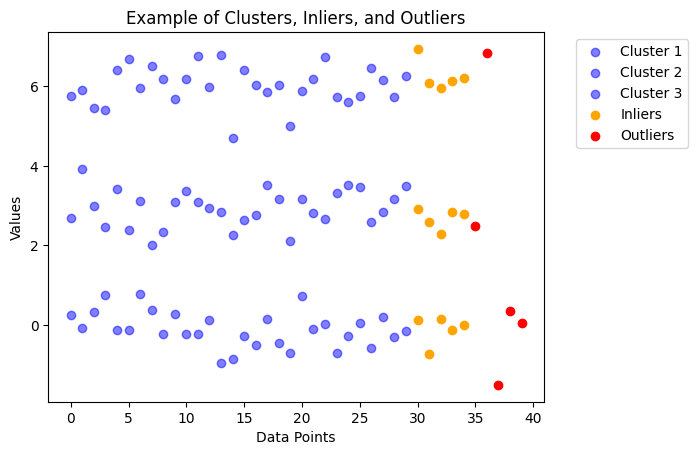

In [ ]:
# Set a random seed for reproducibility
np.random.seed(42)

# Generate clusters of inliers and outliers
num_clusters = 3
num_points_per_cluster = 30
num_outliers = 5
num_inliers_per_cluster = 5

# Move clusters closer
clusters = [np.random.normal(i * 3, 0.5, num_points_per_cluster) for i in range(num_clusters)]  # Adjusted standard deviation to move data points closer
outliers = np.random.normal(2, 5, num_outliers)  # Adjusted mean to move outliers closer to clusters

# Generate and shuffle random inliers for each cluster
inliers_per_cluster = [np.random.normal(i * 3, 0.5, num_inliers_per_cluster) for i in range(num_clusters)]  # Adjusted standard deviation for inliers
for inliers_cluster in inliers_per_cluster:
    np.random.shuffle(inliers_cluster)

# Plot the data
for i, (cluster, inliers_cluster) in enumerate(zip(clusters, inliers_per_cluster), start=1):
    plt.scatter(range(len(cluster)), cluster, label=f'Cluster {i}', alpha=0.5, c='blue')
    plt.scatter(range(len(cluster), len(cluster) + len(inliers_cluster)), inliers_cluster, c='orange')

plt.scatter([], [], c='orange', label='Inliers')  # Empty scatter plot for legend
plt.scatter(range(len(clusters[0]) + len(inliers_per_cluster[0]), len(clusters[0]) + len(inliers_per_cluster[0]) + num_outliers), outliers, c='red', label='Outliers')

# Customize the plot
plt.title('Example of Clusters, Inliers, and Outliers')
plt.xlabel('Data Points')
plt.ylabel('Values')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Set bbox_to_anchor to place legend outside
plt.show()


#2.Anomaly Detection

## 2.1 Univariate --> Point Anomalies

### 2.1.1 Univariate --> Anomalies using Statistics

####################################################################################################

                                         Anomaly Detection                                          

                                              Z-Scores                                              

####################################################################################################



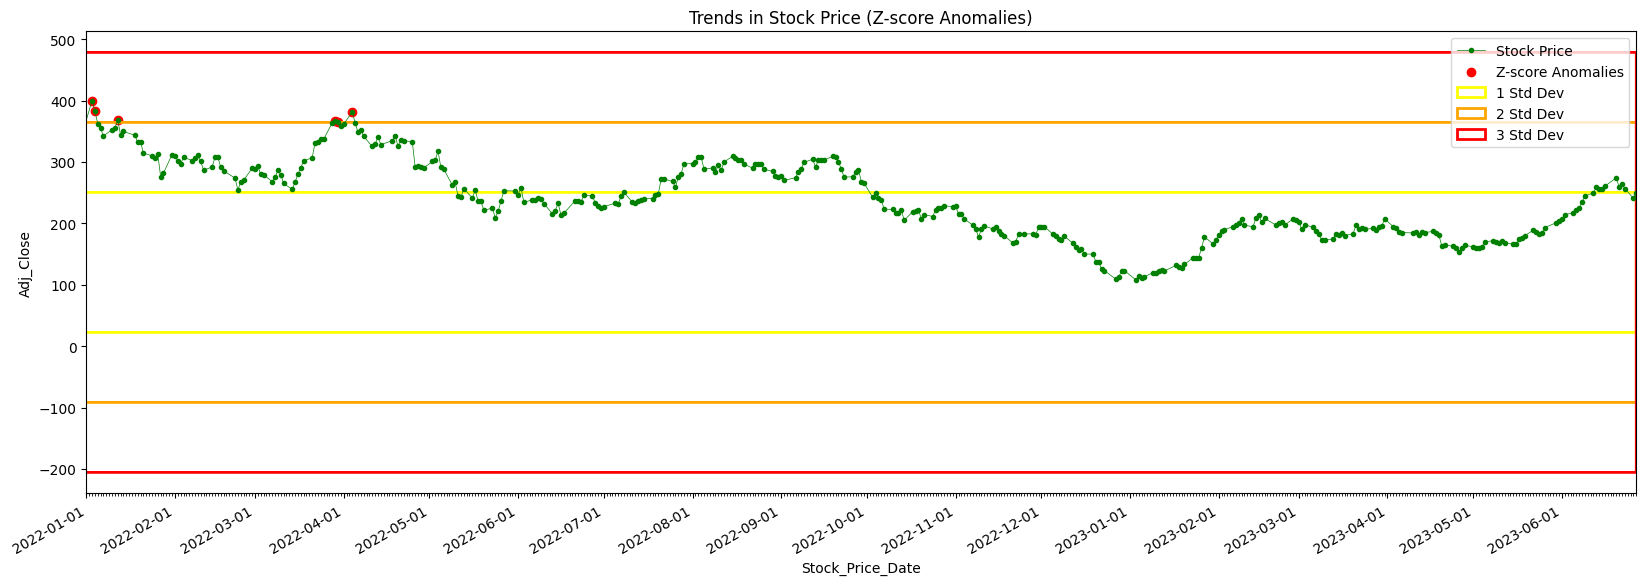

####################################################################################################

                                         Anomaly Detection                                          

                                              Box Plot                                              

####################################################################################################



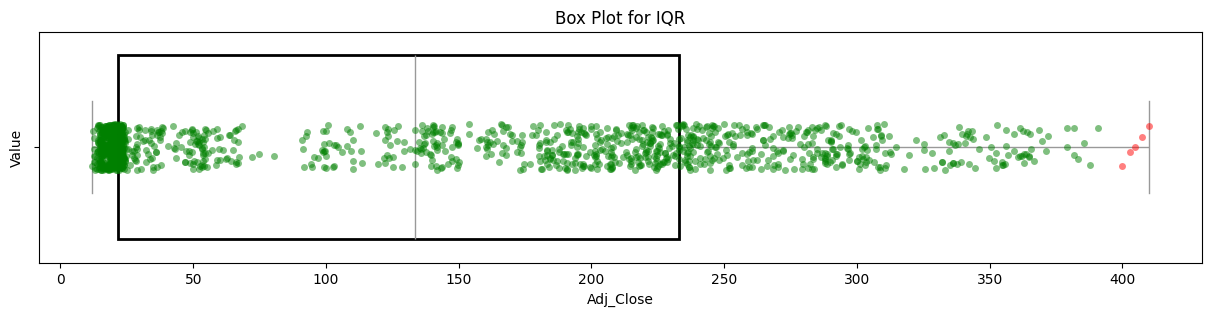

In [ ]:

# ***** Function to help display*****
def print_pretty_header(title, subtitle):
    # Define header formatting
    line_length = 50
    header_padding = 2
    # Calculate the width for the title text
    title_width = line_length * header_padding
    print("#" * title_width + "\n")
    print(title.center(title_width) + "\n")
    if subtitle:
        # Calculate the width for the subtitle text
        subtitle_width = line_length - 2 * header_padding
        print(subtitle.center(title_width) + "\n")
    print("#" * title_width + "\n")

# Function to Retrieve Training Data
def _1_get_data():
    auth.authenticate_user()
    gauth = GoogleAuth()
    gauth.credentials = GoogleCredentials.get_application_default()
    drive = GoogleDrive(gauth)

    colabFileName = 'S3_Ch14_Timeseries.csv'
    dataLink = 'https://drive.google.com/open?id=16r63v-Ctdb1kmE_hGbKrctY4qnGBRznq'   # The shareable link to the file
    ignorestr, id = dataLink.split('=')  # Split the link by '=' and get the id of the file
    downloaded = drive.CreateFile({'id': id})  # Create a PyDrive File instance with the specified file id
    downloaded.GetContentFile(colabFileName)  # Download the file and save it to the local file system
    df_rawdata = pd.read_csv(colabFileName)  # Read the CSV file into a Pandas dataframe
    pd.set_option('display.max_columns', None)
    return df_rawdata

# Function to Apply Z-score Rules
def _2_apply_zscore_rules(df_rawdata):
    z_scores_violations = np.zeros(len(df_rawdata), dtype=bool)

    # Convert columns to numeric
    df_rawdata['Adj_Close'] = pd.to_numeric(df_rawdata['Adj_Close'], errors='coerce')

    # Calculate Z-score
    z_scores = (df_rawdata['Adj_Close'] - df_rawdata['Adj_Close'].mean()) / df_rawdata['Adj_Close'].std()

    # Rule 1 (Z-score)
    z_scores_violations |= np.abs(z_scores) > 2

    return z_scores_violations

# Function to Plot Z-Score Anomalies
def _3_plot_zscore_anomalies(df_rawdata, z_scores_violations):
    # Display data points outside Z-scores
    fig, ax = plt.subplots(figsize=(20, 6))

    df_rawdata['Stock_Price_Date'] = pd.to_datetime(df_rawdata['Stock_Price_Date'], format='%Y-%m-%d')

    # Print Header
    print_pretty_header("Anomaly Detection", "Z-Scores")

    # Plotting different data series
    ax.plot(df_rawdata['Stock_Price_Date'], df_rawdata['Adj_Close'], color='green', marker='.', linestyle='-', linewidth=0.5, label='Stock Price')

    # Calculate Z-scores
    z_scores = (df_rawdata['Adj_Close'] - df_rawdata['Adj_Close'].mean()) / df_rawdata['Adj_Close'].std()

    # Plotting anomalies
    ax.scatter(df_rawdata['Stock_Price_Date'][z_scores_violations], df_rawdata['Adj_Close'][z_scores_violations], color='red', label='Z-score Anomalies')

    # Plotting bordered regions for 1, 2, and 3 standard deviations
    ax.fill_between(df_rawdata['Stock_Price_Date'], df_rawdata['Adj_Close'].mean() - df_rawdata['Adj_Close'].std(), df_rawdata['Adj_Close'].mean() + df_rawdata['Adj_Close'].std(), color='none', edgecolor='yellow', linewidth=2, label='1 Std Dev')
    ax.fill_between(df_rawdata['Stock_Price_Date'], df_rawdata['Adj_Close'].mean() - 2*df_rawdata['Adj_Close'].std(), df_rawdata['Adj_Close'].mean() + 2*df_rawdata['Adj_Close'].std(), color='none', edgecolor='orange', linewidth=2, label='2 Std Dev')
    ax.fill_between(df_rawdata['Stock_Price_Date'], df_rawdata['Adj_Close'].mean() - 3*df_rawdata['Adj_Close'].std(), df_rawdata['Adj_Close'].mean() + 3*df_rawdata['Adj_Close'].std(), color='none', edgecolor='red', linewidth=2, label='3 Std Dev')

    # Set x-axis limits to start from Jan 1, 2022
    start_date = pd.to_datetime('2022-01-01')
    end_date = df_rawdata['Stock_Price_Date'].max()
    ax.set_xlim([start_date, end_date])

    # Format dates on X-axis
    date_format = mdates.DateFormatter('%Y-%m-%d')
    ax.xaxis.set_major_formatter(date_format)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_minor_locator(mdates.DayLocator())

    # Rotate x-axis labels by 30 degrees
    plt.xticks(rotation=30, ha='right')

    ax.legend()
    ax.set_xlabel('Stock_Price_Date')
    ax.set_ylabel('Adj_Close')
    ax.set_title('Trends in Stock Price (Z-score Anomalies)')

    plt.show()

# Function to Apply IQR Rules
def _4_apply_iqr_rules(df_rawdata):
    iqr_multiplier = 0.75
    iqr_violations = np.zeros(len(df_rawdata), dtype=bool)

    # Convert columns to numeric
    df_rawdata['Adj_Close'] = pd.to_numeric(df_rawdata['Adj_Close'], errors='coerce')

    # Calculate IQR
    Q1 = df_rawdata['Adj_Close'].quantile(0.25)
    Q3 = df_rawdata['Adj_Close'].quantile(0.75)
    IQR = Q3 - Q1

    # Rule 2 (IQR)
    iqr_violations |= (df_rawdata['Adj_Close'] < (Q1 - iqr_multiplier * IQR)) | (df_rawdata['Adj_Close'] > (Q3 + iqr_multiplier * IQR))

    return iqr_violations

# Function to Plot Box Plot for IQR
def _5_plot_iqr_box_plot(df_rawdata, iqr_violations):
    # Print Header
    print_pretty_header("Anomaly Detection", "Box Plot")

    # Display box plot for IQR with outliers in red and normal values in green
    fig, ax = plt.subplots(figsize=(15, 3))

    # Set color='white' to avoid filling, and set outliers in red
    sns.boxplot(x=df_rawdata['Adj_Close'], color='white', fliersize=0, ax=ax, boxprops=dict(edgecolor='black', linewidth=2), flierprops=dict(markerfacecolor='red', marker='o', markersize=8))

    # Add jittered points for better visualization, outliers in red, normal values in green
    sns.stripplot(x=df_rawdata['Adj_Close'][iqr_violations], jitter=True, color='red', alpha=0.5, ax=ax)
    sns.stripplot(x=df_rawdata['Adj_Close'][~iqr_violations], jitter=True, color='green', alpha=0.5, ax=ax)

    ax.set_xlabel('Adj_Close')
    ax.set_ylabel('Value')
    ax.set_title('Box Plot for IQR')

    plt.show()

# Define Main Workflow
def main():
    # 0. Start the timer
    start_time = time.time()

    # Step 1. Get Data
    df_rawdata = _1_get_data()
    df_rawdata.rename(columns={'Date': 'Stock_Price_Date', 'Adj Close': 'Adj_Close'}, inplace=True)

    # Convert 'Stock_Price_Date' to datetime format
    df_rawdata['Stock_Price_Date'] = pd.to_datetime(df_rawdata['Stock_Price_Date'])

    # Sort DataFrame by date
    df_rawdata.sort_values('Stock_Price_Date', inplace=True)

    # Step 2. Apply Z-score Rules
    z_scores_violations = _2_apply_zscore_rules(df_rawdata)

    # Step 3. Plot Z-Score Anomalies
    _3_plot_zscore_anomalies(df_rawdata, z_scores_violations)

    # Step 4. Apply IQR Rules
    iqr_violations = _4_apply_iqr_rules(df_rawdata)

    # Step 5. Plot Box Plot for IQR
    _5_plot_iqr_box_plot(df_rawdata, iqr_violations)

    return df_rawdata

if __name__ == "__main__":
    df_rawdata = main()  # Call main()


### 2.1.2 Univariate --> Anomalies using ML

46/46 [==============================] - 0s 1ms/step
####################################################################################################

                                         Anomaly Detection                                          

                                              Using ML                                              

####################################################################################################



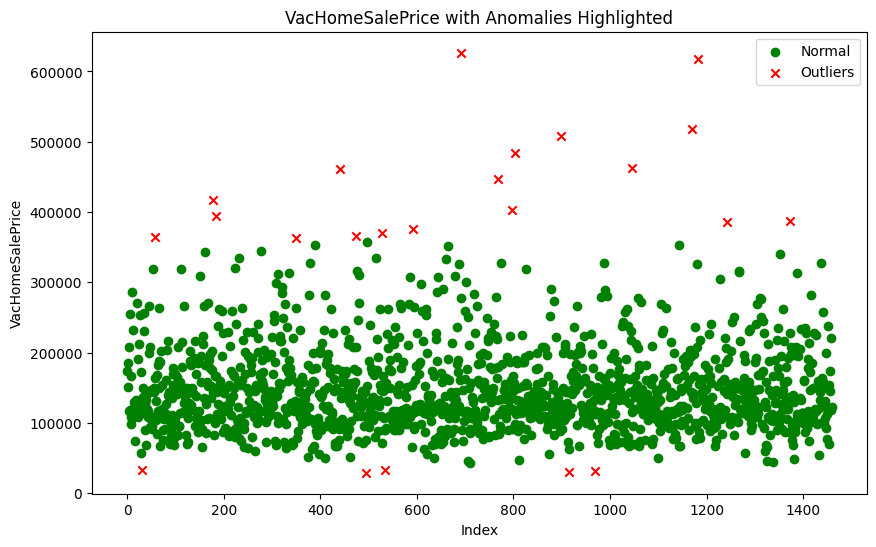

In [ ]:
# Local Imports and variables
n_neighbors = [1, 3, 5]  # List of integers to loop through for KNN

# ***** Function to help display*****
def print_pretty_header(title, subtitle):
    # Define header formatting
    line_length = 50
    header_padding = 2
    # Calculate the width for the title text
    title_width = line_length  * header_padding
    print("#" * title_width + "\n")
    print(title.center(title_width) + "\n")
    if subtitle:
        # Calculate the width for the subtitle text
        subtitle_width = line_length - 2 * header_padding
        print(subtitle.center(title_width)+ "\n")
    print("#" * title_width + "\n")

# Function to Retrieve Training Data
def _1_get_data():
    auth.authenticate_user()
    gauth = GoogleAuth()
    gauth.credentials = GoogleCredentials.get_application_default()
    drive = GoogleDrive(gauth)

    colabFileName = 'S2_Ch6_Data_Quality_Engineering_data.csv'
    dataLink = 'https://drive.google.com/open?id=1h_Akm5JR06mz0yeM5jmhTfbOBDJngifp'  # The shareable link to the file
    ignorestr, id = dataLink.split('=')  # Split the link by '=' and get the id of the file
    downloaded = drive.CreateFile({'id':id})  # Create a PyDrive File instance with the specified file id
    downloaded.GetContentFile(colabFileName)  # Download the file and save it to the local file system
    df_rawdata = pd.read_csv(colabFileName)  # Read the CSV file into a Pandas dataframe
    pd.set_option('display.max_columns', None)
    return df_rawdata

# Function to Define Variables
def _2_define_variables():
    anomaly_evaluation_columns = ['Data', 'Algorithm', 'Anomaly Scores', 'Duration']
    anomaly_detect_column = ['VacHomeSalePrice']
    return anomaly_evaluation_columns, anomaly_detect_column

# Functions for Data Processing and Encoding
def _3_preprocess_data(df_rawdata, anomaly_detect_column):
    # Impute NaN values
    preprocessed_data = df_rawdata[anomaly_detect_column].copy()
    return preprocessed_data

def _5_evaluate_unsupervised_models(anomaly_result_df, data, clf_name, anomaly_scores, duration):

    new_row = {
        'Data': data,
        'Algorithm': clf_name,
        'Anomaly Scores': anomaly_scores,
        'Duration': duration
    }
    # Append the new row to the DataFrame
    anomaly_result_df = pd.concat([anomaly_result_df, pd.DataFrame([new_row])], ignore_index=True)

    return anomaly_result_df

def _4_train_model(df_rawdata, pca_df,anomalies_df, anomaly_result_df, target_columns):
    outliers_fraction = 0.1
    clusters_separation = [0]
    random_state = np.random.RandomState(42)

    # Retrieve the number of features in your preprocessed data
    num_features = 1

    # Adjust the hidden_neurons parameter
    hidden_neurons = [num_features // 2, num_features // 4, num_features // 2]

    # Scale the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(pca_df)

    algorithms = {
          '1. Proximity : Local Outlier Factor (LOF)' : LOF(n_neighbors=20, algorithm='auto', leaf_size=30, metric='minkowski', p=2, metric_params=None, contamination=outliers_fraction, n_jobs=1)
        , '2. Proximity : Connectivity-Based Outlier Factor (COF) ' : COF(contamination=outliers_fraction, n_neighbors=20)
        , '3. Proximity : Cluster-based Local Outlier Factor (CBLOF)':CBLOF(contamination=outliers_fraction,check_estimator=False, random_state=random_state)
        , '4. Proximity : Histogram-base Outlier Detection (HBOS)' : HBOS(contamination=outliers_fraction)
        , '5. Proximity : K Nearest Neighbors (KNN)': KNN(contamination=outliers_fraction, n_neighbors=5, method='largest', radius=1.0, algorithm='auto', leaf_size=30, metric='minkowski', p=2, metric_params=None, n_jobs=1)
        , '6. Probablistic : Fast Angle-Based Outlier Detection using approximation (FastABOD)': ABOD(contamination=outliers_fraction ,n_neighbors=5, method='fast')
        , '7. Outliers Ensembles "Isolation Forest' :  IForest(contamination=outliers_fraction, random_state=random_state)
        , '8. Neural Networks : AutoEncoder': AutoEncoder(hidden_neurons=hidden_neurons, contamination=outliers_fraction, verbose=False)
    }

    for i, (clf_name, clf) in enumerate(algorithms.items()):
        # print(clf_name)

        # fit the data and tag outliers
        t0 = time.time()

        # Fit the model to your data (no need to specify a specific model like 'ocsvm_model')
        clf.fit(X_scaled)
        anomaly_scores = clf.decision_function(X_scaled)
        pca_df[clf_name] = (anomaly_scores > 0).astype(int)

      # Apply thresholding
        threshold_percentile = 95  # Set your desired percentile
        threshold = np.percentile(anomaly_scores, threshold_percentile)
        col_name = clf_name + '_score'
        anomalies_df[col_name] = (anomaly_scores > threshold).astype(int)

        duration = round(time.time() - t0, 2)
        anomaly_result_df = _5_evaluate_unsupervised_models(anomaly_result_df, target_columns, clf_name, anomaly_scores, duration)

        # Create a new column 'Total_Outliers' to count the number of algorithms flagging a data point as an outlier
        score_columns = [col for col in anomalies_df.columns if col.endswith('_score')]
        anomalies_df['Total_Outliers'] = anomalies_df[score_columns].sum(axis=1)

        # Create a new column 'Outlier_Flag' based on the total number of outliers
        anomalies_df['Outlier_Flag'] = anomalies_df['Total_Outliers'] > 4

    # Plot VacHomeSalePrice from anomalies_df
    plt.figure(figsize=(10, 6))

    # Plot normal values in green
    normal_values = anomalies_df[~anomalies_df['Outlier_Flag']]
    plt.scatter(normal_values.index, normal_values['VacHomeSalePrice'], c='green', label='Normal', marker='o')

    # Plot VacHomeSalePrice in red when Outlier_Flag is true
    outliers = anomalies_df[anomalies_df['Outlier_Flag']]
    plt.scatter(outliers.index, outliers['VacHomeSalePrice'], c='red', label='Outliers', marker='x')

    # Print Header
    print_pretty_header("Anomaly Detection", "Using ML")

    # Set plot labels and title
    plt.xlabel('Index')
    plt.ylabel('VacHomeSalePrice')
    plt.title('VacHomeSalePrice with Anomalies Highlighted')

    # Show legend
    plt.legend()

    # Show the plot
    plt.show()

    return anomalies_df, anomaly_result_df

# Define Main Workflow
def main():
    # 0. Start the timer
    start_time = time.time()

    # Step 1. Get  Data
    df_rawdata = _1_get_data()

    # Step 2. Define Variables
    anomaly_evaluation_columns, target_columns = _2_define_variables()
    anomaly_result_df = pd.DataFrame(columns=anomaly_evaluation_columns)

    # Step 3. Preprocess data
    preprocessed_data = _3_preprocess_data(df_rawdata, target_columns)

    # Create a DataFrame to store anomaly information
    # anomalies_df = pd.DataFrame(index=preprocessed_data.index)
    anomalies_df = df_rawdata.copy()

    # Step 4. Train models and find anomalies
    anomalies_df, anomaly_result_df = _4_train_model(df_rawdata, preprocessed_data , anomalies_df, anomaly_result_df, target_columns)

    return anomalies_df, anomaly_result_df

if __name__ == "__main__":
    anomalies_df, anomaly_result_df = main()  # Call main() and store the result in binary_result_df
    anomalies_df  # Now you can access binary_result_df
    anomaly_result_df


## 2.2 Univariate --> Anomalies using Statistical Process Control Run Charts

####################################################################################################

                                         Anomaly Detection                                          

                 Detecting trends using Statistical Process Control ( Nelson Rules)                 

####################################################################################################



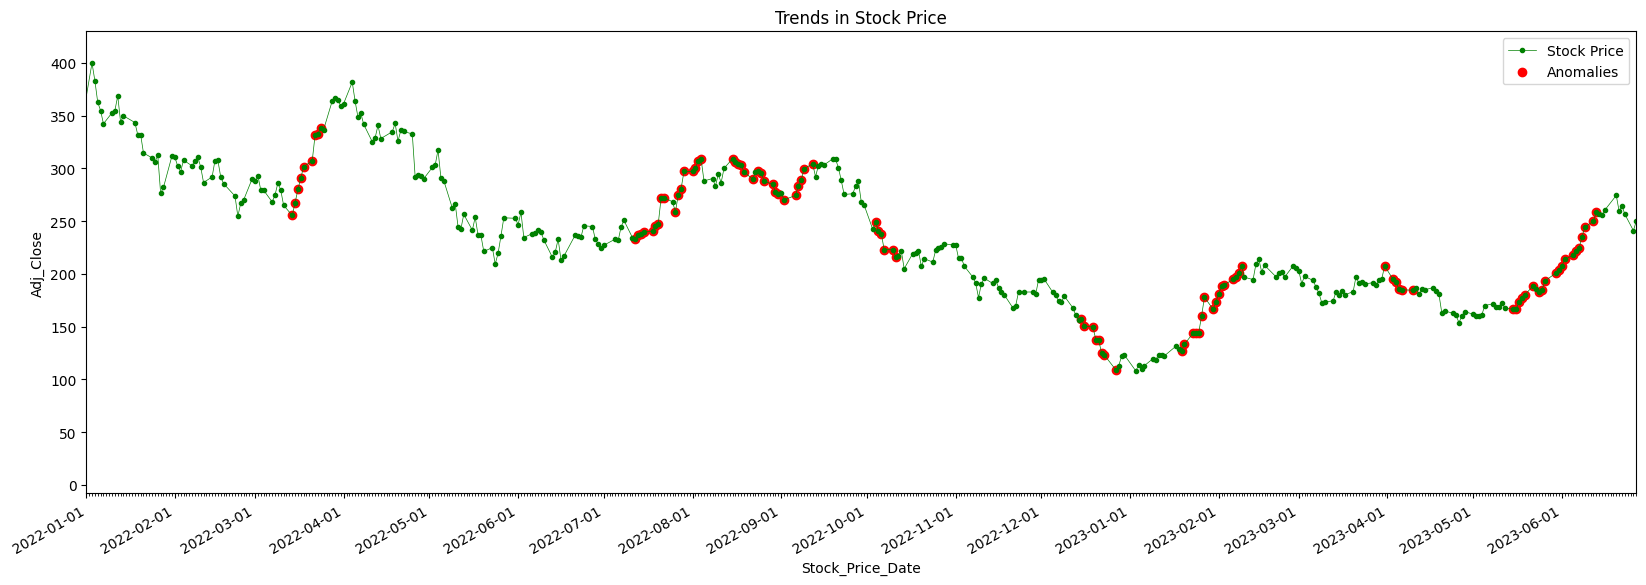

In [ ]:
# Standard Library Imports
import time
import random
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt  # Add this line for matplotlib
import matplotlib.dates as mdates

# ***** Function to help display*****
def print_pretty_header(title, subtitle):
    # Define header formatting
    line_length = 50
    header_padding = 2
    # Calculate the width for the title text
    title_width = line_length * header_padding
    print("#" * title_width + "\n")
    print(title.center(title_width) + "\n")
    if subtitle:
        # Calculate the width for the subtitle text
        subtitle_width = line_length - 2 * header_padding
        print(subtitle.center(title_width) + "\n")
    print("#" * title_width + "\n")

# Function to Retrieve Training Data
def _1_get_data():
    auth.authenticate_user()
    gauth = GoogleAuth()
    gauth.credentials = GoogleCredentials.get_application_default()
    drive = GoogleDrive(gauth)

    colabFileName = 'S3_Ch14_Timeseries.csv'
    dataLink = 'https://drive.google.com/open?id=16r63v-Ctdb1kmE_hGbKrctY4qnGBRznq'   # The shareable link to the file
    ignorestr, id = dataLink.split('=')  # Split the link by '=' and get the id of the file
    downloaded = drive.CreateFile({'id': id})  # Create a PyDrive File instance with the specified file id
    downloaded.GetContentFile(colabFileName)  # Download the file and save it to the local file system
    df_rawdata = pd.read_csv(colabFileName)  # Read the CSV file into a Pandas dataframe
    pd.set_option('display.max_columns', None)
    return df_rawdata

def apply_nelson_rules(data, adj_close, sigma_col):
    # Initialize a boolean mask for violations
    violations = np.zeros(len(data), dtype=bool)

    # Convert columns to numeric
    data[adj_close] = pd.to_numeric(data[adj_close], errors='coerce')
    data[sigma_col] = pd.to_numeric(data[sigma_col], errors='coerce')

    # Reset indices
    data.reset_index(drop=True, inplace=True)

    # Rule 1
    violations |= data[adj_close] - data[adj_close].shift(1) > 3 * data[sigma_col]

    # Rule 2
    for i in range(len(data) - 8):
        violations[i:i+9] |= all(data.loc[i:i+8, adj_close] > data.loc[i+8, adj_close])

    # Rule 3
    for i in range(len(data) - 5):
        violations[i:i+6] |= all(np.diff(data.loc[i:i+5, adj_close]) > 0) or all(np.diff(data.loc[i:i+5, adj_close]) < 0)

    # Rule 4
    for i in range(len(data) - 13):
        violations[i:i+14] |= all(np.diff(data.loc[i:i+13, adj_close]) > 0) or all(np.diff(data.loc[i:i+13, adj_close]) < 0)

    # Rule 5
    for i in range(len(data) - 2):
        diff_condition = np.abs(data.loc[i:i+2, adj_close] - data.loc[i:i+2, adj_close].shift(1)) > 2 * data.loc[i+2, sigma_col]
        violations[i:i+3] |= np.sum(diff_condition) >= 2

    # Rule 6
    for i in range(len(data) - 4):
        diff_condition = np.abs(data.loc[i:i+4, adj_close] - data.loc[i:i+4, adj_close].shift(1)) > data.loc[i+4, sigma_col]
        violations[i:i+5] |= np.sum(diff_condition) >= 4

    # Rule 7
    for i in range(len(data) - 14):
        abs_diff_condition = (
            (1 <= np.abs(data.loc[i:i+14, adj_close] - data.loc[i:i+14, adj_close].shift(1)) / data.loc[i:i+14, sigma_col]) &
            (np.abs(data.loc[i:i+14, adj_close] - data.loc[i:i+14, adj_close].shift(1)) / data.loc[i:i+14, sigma_col] <= 2)
        )
        violations[i:i+15] |= all(abs_diff_condition)

    # Rule 8
    for i in range(len(data) - 7):
        violations[i:i+8] |= all(data.loc[i:i+7, adj_close] > data.loc[i+7, adj_close]) or all(data.loc[i:i+7, adj_close] < data.loc[i+7, adj_close])

    return violations

def plot_anomalies(df_rawdata, violations):
    fig, ax = plt.subplots(figsize=(20, 6))

    df_rawdata['Stock_Price_Date'] = pd.to_datetime(df_rawdata['Stock_Price_Date'], format='%Y-%m-%d')

    # Print Header
    print_pretty_header("Anomaly Detection", "Detecting trends using Statistical Process Control ( Nelson Rules)")

    # Plotting different data series
    ax.plot(df_rawdata['Stock_Price_Date'], df_rawdata['Adj_Close'], color='green', marker='.', linestyle='-', linewidth=0.5, label='Stock Price')
    ax.scatter(df_rawdata['Stock_Price_Date'][violations], df_rawdata['Adj_Close'][violations], color='red', label='Anomalies')

    # Set x-axis limits to start from Jan 1, 2022
    start_date = pd.to_datetime('2022-01-01')
    end_date = df_rawdata['Stock_Price_Date'].max()
    ax.set_xlim([start_date, end_date])

    # Format dates on X-axis
    date_format = mdates.DateFormatter('%Y-%m-%d')
    ax.xaxis.set_major_formatter(date_format)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_minor_locator(mdates.DayLocator())

    # Rotate x-axis labels by 30 degrees
    plt.xticks(rotation=30, ha='right')

    ax.legend()
    ax.set_xlabel('Stock_Price_Date')
    ax.set_ylabel('Adj_Close')
    ax.set_title('Trends in Stock Price')

    plt.show()
    return

# Define Main Workflow
def main():
    # 0. Start the timer
    start_time = time.time()

    # Step 1. Get Data
    df_rawdata = _1_get_data()

    # Rename columns
    df_rawdata.rename(columns={'Date': 'Stock_Price_Date', 'Adj Close': 'Adj_Close'}, inplace=True)

    # Convert 'Stock_Price_Date' to datetime format
    df_rawdata['Stock_Price_Date'] = pd.to_datetime(df_rawdata['Stock_Price_Date'])

    # Sort DataFrame by date
    df_rawdata.sort_values('Stock_Price_Date', inplace=True)

    # Assuming df_rawdata contains your data with 'Value' as the column to check
    violations = apply_nelson_rules(df_rawdata, 'Adj_Close', 'Adj_Close')

    plot_anomalies(df_rawdata, violations)
    return df_rawdata

if __name__ == "__main__":
    df_rawdata = main()  # Call main()


------------- End of **S3_Ch15_AnomalyDetection Chapter Code** for **Applied Machine Learning for Data Science Practitioners** ------------ Vidya Subramanian ------------------